In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/cross_tech_ann.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 297 × 920
    obs: 'Raw.file', 'celltype', 'cvm', 'RI', 'batch'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 297 cells × 920 proteins
Batches (3): ['pSCoPE1', 'pSCoPE2', 'shotgun']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.1
lambda_adv=0.3
lambda_mse=0.5
lr = 0.01
epochs = 1000
warmup = 1
md = 'cross_tech'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=1.9349 | recon=1.2860 | mse=0.7871 | cls=0.5484 | adv=0.6686 |lr=0.01
Epoch   20 | total=3.4672 | recon=1.2570 | mse=0.7594 | cls=0.7590 | adv=5.8484 |lr=0.009000000000000001
Epoch   30 | total=2.1872 | recon=1.2704 | mse=0.7574 | cls=0.6822 | adv=1.5664 |lr=0.007290000000000001
Epoch   40 | total=2.7627 | recon=1.2604 | mse=0.7570 | cls=0.6636 | adv=3.5246 |lr=0.005904900000000002
Epoch   50 | total=2.4538 | recon=1.2081 | mse=0.7196 | cls=0.7932 | adv=2.6887 |lr=0.005314410000000002
Epoch   60 | total=2.2125 | recon=1.2070 | mse=0.7254 | cls=0.4070 | adv=2.0071 |lr=0.004304672100000002
Epoch   70 | total=2.2482 | recon=1.2010 | mse=0.7140 | cls=0.3381 | adv=2.1879 |lr=0.003486784401000002
Epoch   80 | total=2.0778 | recon=1.1807 | mse=0.7003 | cls=0.2630 | adv=1.7353 |lr=0.003138105960900002
Epoch   90 | total=2.1073 | recon=1.1800 | mse=0.7005 | cls=0.2433 | adv=1.8425 |lr=0.0025418658283290017
Epoch  100 | total=2.0251 | recon=1.1817 | mse=0.7057 | cls=0.1875 | a

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/cross_tech_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.svg


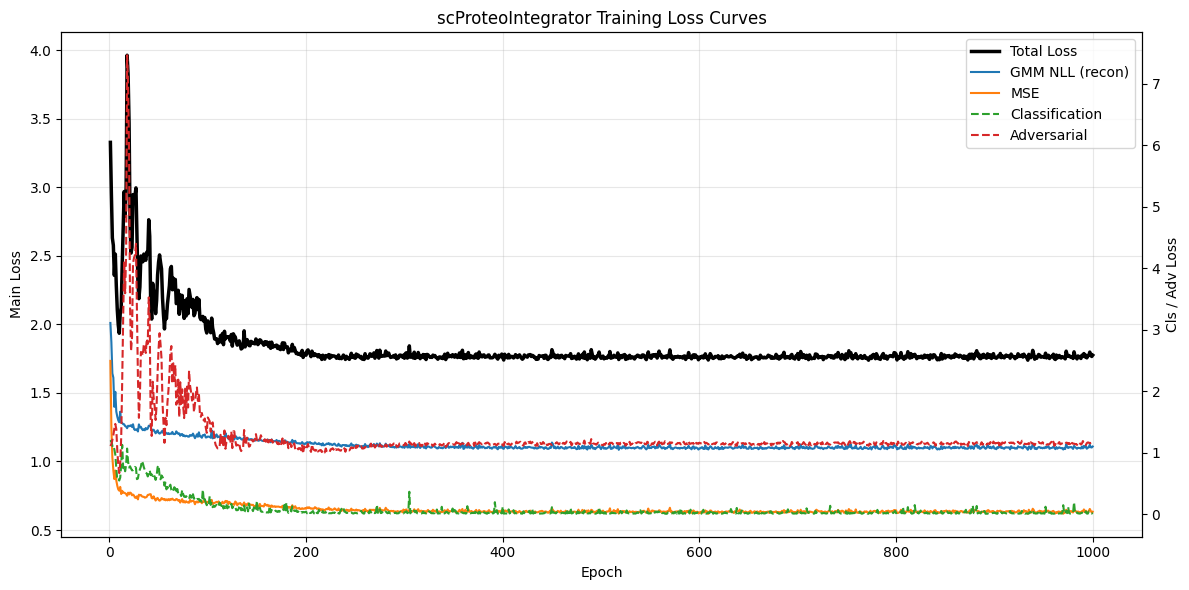

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/cross_tech_cls-0.1_adv-0.3_mse-0.5_warmup-1_lr-0.01_epoch-1000.pt
